In [1]:
from sparseDPD import DataManager, Volterra, PGJANET_NeuralNetwork, PNTDNN_NeuralNetwork, Datapath, AdaptiveDatapathPruningExperiment
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load in an OpenDPD dataset

openDPD_folder = 'OpenDPD_datasets/DPA_160MHz'

#40,000 points
openDPD_dataManager = DataManager(
    num_test_points=2000,
    num_training_points=23040,
    num_validaiton_points=7680,
    openDPD_test_input_file=f'{openDPD_folder}/test_input.csv',
    openDPD_test_output_file=f'{openDPD_folder}/test_output.csv',
    openDPD_training_input_file=f'{openDPD_folder}/train_input.csv',
    openDPD_training_output_file=f'{openDPD_folder}/train_output.csv',
    openDPD_validation_input_file=f'{openDPD_folder}/val_input.csv',
    openDPD_validation_output_file=f'{openDPD_folder}/val_output.csv'
)


In [3]:
# DPA dataset parameters (IFFT-concatenated frames, no cyclic prefix)
fs = 640e6  # Sampling frequency: 640 MHz
bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
n_sub_ch = 4  # Number of sub-channels
nperseg = 16384  # FFT size (frame length)

# Get the PA input signal (clean transmitted signal before PA distortion)
input_signal = openDPD_dataManager.training_dataset.input_data
print(f"Signal shape: {input_signal.shape}")
print(f"Signal type: {input_signal.dtype}")
print(f"Number of samples: {len(input_signal)}")

Signal shape: (23040,)
Signal type: complex128
Number of samples: 23040


In [4]:
# Use all available data (train + validation + test) for better constellation
# The training data alone only has ~1 frame, which is insufficient
input_signal = openDPD_dataManager.input_data  # All 32,768 samples
print(f"Using full dataset - Signal shape: {input_signal.shape}")
print(f"Number of complete frames: {len(input_signal) // nperseg}")

Using full dataset - Signal shape: (491520,)
Number of complete frames: 30


In [5]:
# IFFT-Frame Demodulation for DPA datasets
# DPA signals are back-to-back IFFT frames without cyclic prefix

# Calculate number of active subcarriers per carrier
bin_spacing = fs / nperseg
n_active = int(round(bw_sub_ch / bin_spacing))
n_half = n_active // 2

# Calculate carrier center frequencies (Hz) and FFT bin indices
# Carriers are symmetrically placed around DC
carrier_f_shifts = [(i - (n_sub_ch - 1) / 2) * bw_sub_ch for i in range(n_sub_ch)]
dc = nperseg // 2
carrier_centres = [dc + int(round(f / bin_spacing)) for f in carrier_f_shifts]

print(f"Carrier frequency offsets (MHz): {[f/1e6 for f in carrier_f_shifts]}")
print(f"Carrier FFT bin centers: {carrier_centres}")
print(f"Active subcarriers per carrier: {n_active}")
print(f"Bin spacing: {bin_spacing/1e6:.3f} MHz")

Carrier frequency offsets (MHz): [-60.0, -20.0, 20.0, 60.0]
Carrier FFT bin centers: [6656, 7680, 8704, 9728]
Active subcarriers per carrier: 1024
Bin spacing: 0.039 MHz



Debug - Single frame, single carrier:
Frame samples: 16384
Carrier center bin: 7680
Extracted subcarriers: 1024
Mean magnitude: 66.85


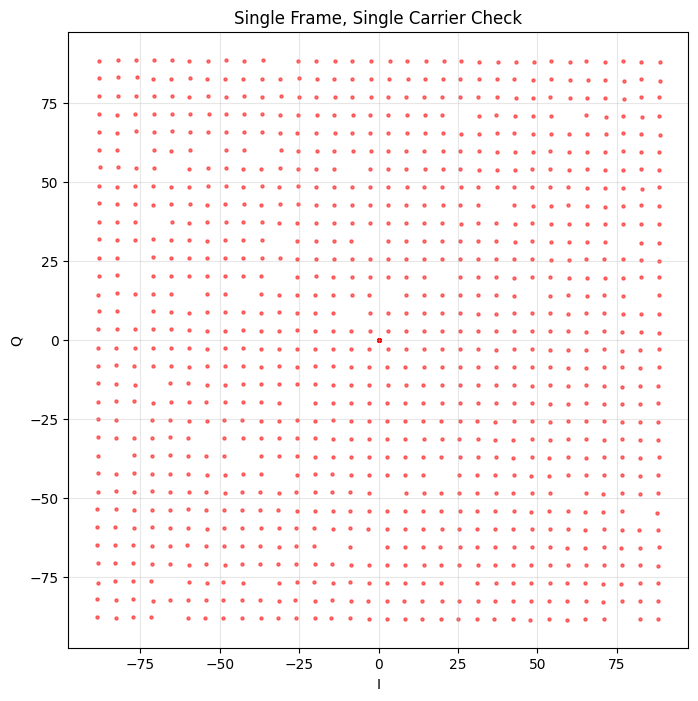

In [6]:
# Debug: Check a single frame to verify demodulation
test_frame = input_signal[:nperseg]
test_fd = np.fft.fftshift(np.fft.fft(test_frame))

# Extract from one carrier
test_cc = carrier_centres[1]  # Pick the second carrier (-20 MHz)
test_sc_neg = test_fd[test_cc - n_half:test_cc]
test_sc_pos = test_fd[test_cc + 1:test_cc + n_half + 1]
test_sc = np.concatenate([test_sc_neg, test_sc_pos])

print(f"\nDebug - Single frame, single carrier:")
print(f"Frame samples: {len(test_frame)}")
print(f"Carrier center bin: {test_cc}")
print(f"Extracted subcarriers: {len(test_sc)}")
print(f"Mean magnitude: {np.mean(np.abs(test_sc)):.2f}")

# Quick plot of just this one carrier from one frame
plt.figure(figsize=(8, 8))
plt.scatter(test_sc.real, test_sc.imag, alpha=0.5, s=5, c='red')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('Single Frame, Single Carrier Check')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

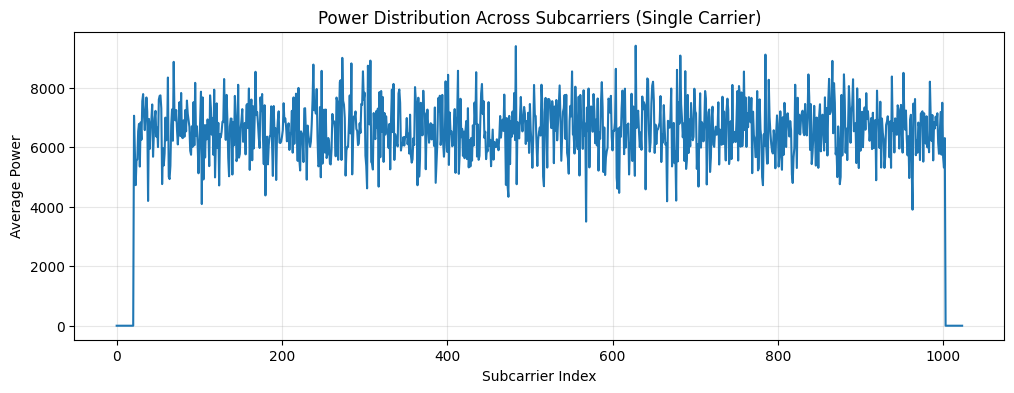

Median power: 6551.84
Power range: 0.00 to 9417.14


In [7]:
# Check power distribution across all frames for one carrier to identify guard bands
all_frames_power = []
n_frames_available = len(input_signal) // nperseg
for i in range(min(20, n_frames_available)):  # Sample first 20 frames
    frame = input_signal[i * nperseg:(i + 1) * nperseg]
    fd = np.fft.fftshift(np.fft.fft(frame))
    cc = carrier_centres[1]
    sc_neg = fd[cc - n_half:cc]
    sc_pos = fd[cc + 1:cc + n_half + 1]
    sc = np.concatenate([sc_neg, sc_pos])
    all_frames_power.append(np.abs(sc) ** 2)

avg_power = np.mean(all_frames_power, axis=0)

plt.figure(figsize=(12, 4))
plt.plot(avg_power)
plt.xlabel('Subcarrier Index')
plt.ylabel('Average Power')
plt.title('Power Distribution Across Subcarriers (Single Carrier)')
plt.grid(True, alpha=0.3)
plt.show()

#Find median of non-zero power
median_power = np.median(avg_power[avg_power > 0])
print(f"Median power: {median_power:.2f}")
print(f"Power range: {np.min(avg_power):.2f} to {np.max(avg_power):.2f}")

In [8]:
# Compute average power per subcarrier across many frames to create a mask
# This identifies guard bands and low-power subcarriers
n_frames_available = len(input_signal) // nperseg
sample_frames = min(50, n_frames_available)
all_powers = []

for i in range(sample_frames):
    frame = input_signal[i * nperseg:(i + 1) * nperseg]
    fd = np.fft.fftshift(np.fft.fft(frame))
    for cc in carrier_centres:
        sc_neg = fd[cc - n_half:cc]
        sc_pos = fd[cc + 1:cc + n_half + 1]
        sc = np.concatenate([sc_neg, sc_pos])
        all_powers.append(np.abs(sc) ** 2)

avg_power_per_subcarrier = np.mean(all_powers, axis=0)

# Create mask: keep only subcarriers with power > 1% of median
median_power = np.median(avg_power_per_subcarrier[avg_power_per_subcarrier > 0])
mask = avg_power_per_subcarrier > 0.01 * median_power

print(f"Frames available: {n_frames_available}")
print(f"Frames sampled for mask: {sample_frames}")
print(f"Total subcarriers: {len(mask)}")
print(f"Active (data) subcarriers: {np.sum(mask)}")
print(f"Guard/pilot subcarriers: {len(mask) - np.sum(mask)}")

Frames available: 30
Frames sampled for mask: 30
Total subcarriers: 1024
Active (data) subcarriers: 982
Guard/pilot subcarriers: 42


In [9]:
# Extract subcarriers for all frames and carriers, applying the mask
n_frames = len(input_signal) // nperseg
all_subcarriers = []

for i in range(n_frames):
    frame = input_signal[i * nperseg:(i + 1) * nperseg]
    fd = np.fft.fftshift(np.fft.fft(frame))
    
    for cc in carrier_centres:
        # Extract ±n_half bins around carrier center (excluding DC)
        sc_neg = fd[cc - n_half:cc]
        sc_pos = fd[cc + 1:cc + n_half + 1]
        sc = np.concatenate([sc_neg, sc_pos])
        
        # Apply mask to keep only active subcarriers
        sc_active = sc[mask]
        all_subcarriers.append(sc_active)

# Combine all subcarriers
qam_symbols = np.concatenate(all_subcarriers)

# Normalize globally by RMS (consistent with the demodulator example)
rms = np.sqrt(np.mean(np.abs(qam_symbols) ** 2) + 1e-30)
qam_symbols = qam_symbols / rms

print(f"\nTotal QAM symbols extracted: {len(qam_symbols):,}")
print(f"Active subcarriers per frame per carrier: {np.sum(mask)}")
print(f"Total frames: {n_frames}, Total carriers: {n_sub_ch}")
print(f"Global RMS normalization factor: {rms:.2f}")


Total QAM symbols extracted: 117,840
Active subcarriers per frame per carrier: 982
Total frames: 30, Total carriers: 4
Global RMS normalization factor: 81.30


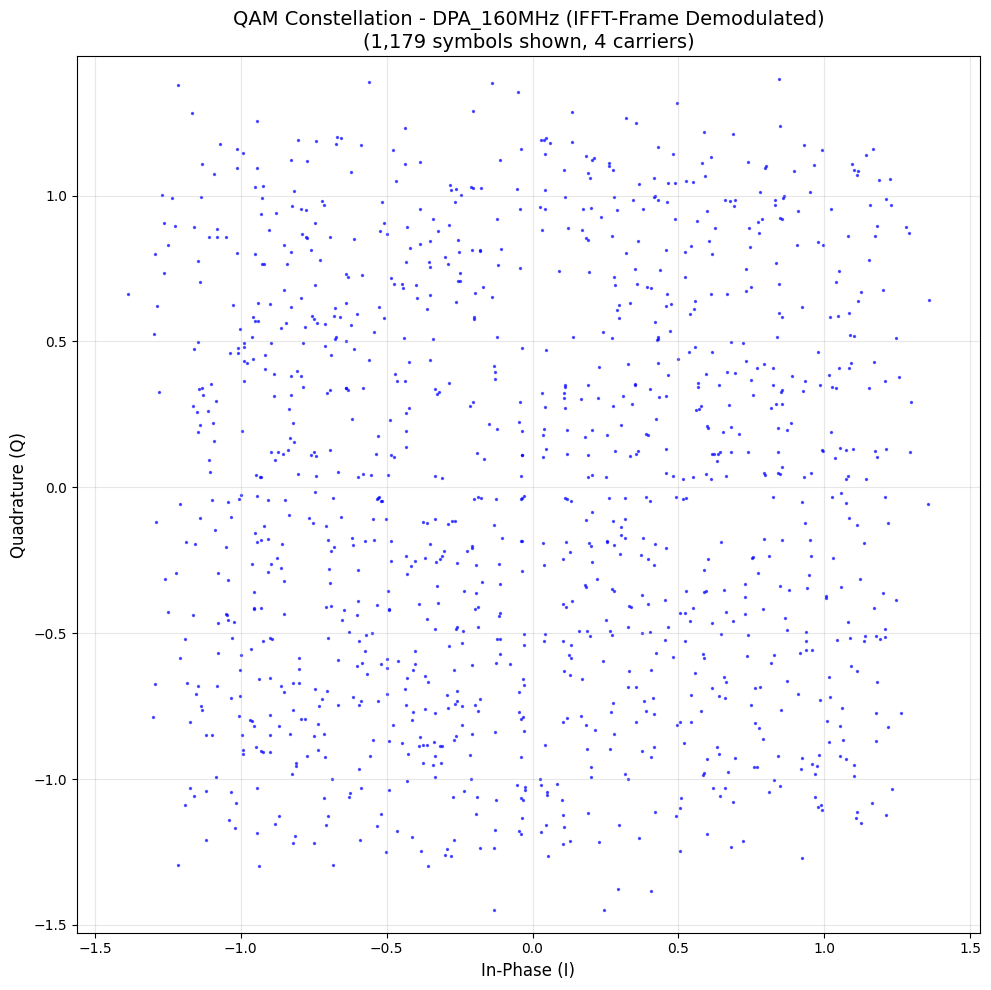


Plotted 1,179 symbols (downsampled from 117,840)


In [10]:
# Plot QAM constellation
plt.figure(figsize=(10, 10))

# Downsample for visualization
downsample_factor = 100
qam_plot = qam_symbols[::downsample_factor]

# Plot I (real) vs Q (imaginary) components
plt.scatter(qam_plot.real, qam_plot.imag, alpha=0.6, s=2, c='blue')

plt.xlabel('In-Phase (I)', fontsize=12)
plt.ylabel('Quadrature (Q)', fontsize=12)
plt.title(f'QAM Constellation - DPA_160MHz (IFFT-Frame Demodulated)\n({len(qam_plot):,} symbols shown, {n_sub_ch} carriers)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"\nPlotted {len(qam_plot):,} symbols (downsampled from {len(qam_symbols):,})")

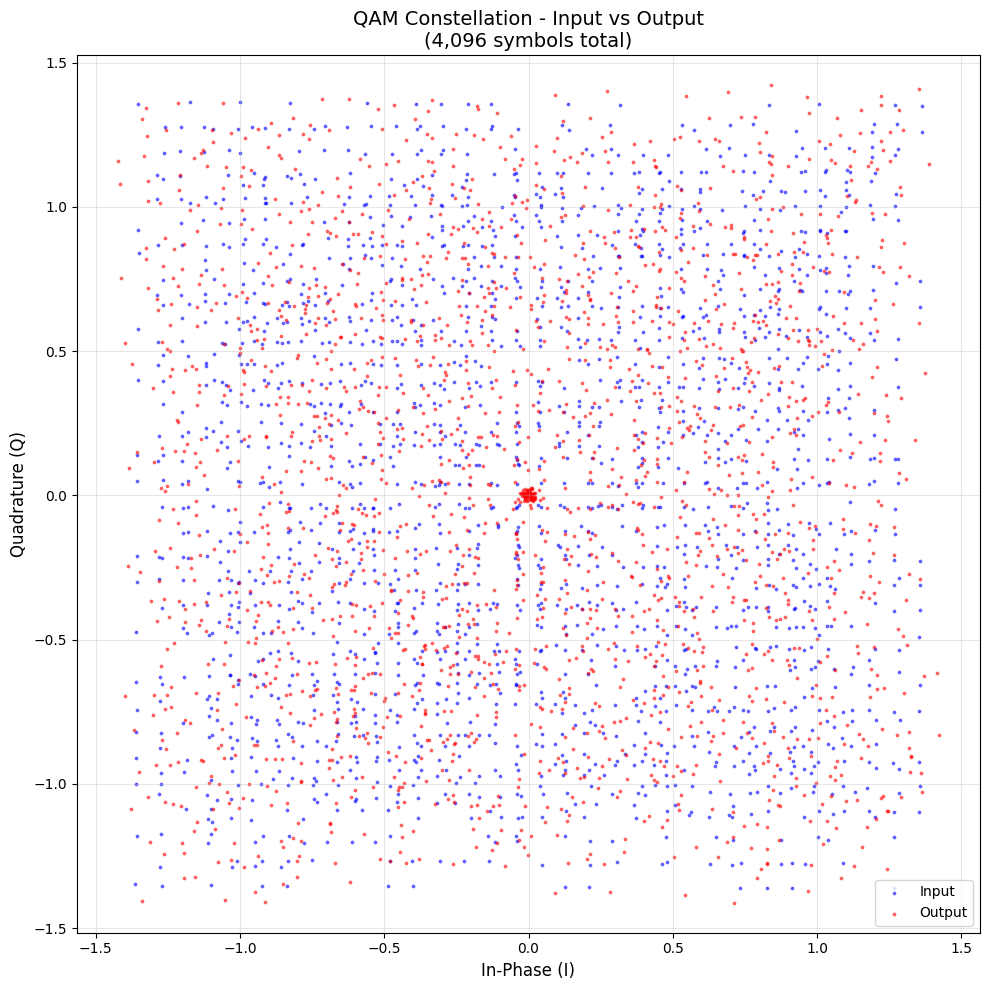

In [11]:
# Example usage: Create a dummy datapath and plot constellation
# For demonstration, we'll use the same signal as input and output
# In real usage, you'd have a trained datapath with actual forward/inverse models

from sparseDPD import Datapath, Volterra

# Create dummy models (just for testing the plot function)
dummy_forward = Volterra(num_nl_orders=3, num_memory_levels=5, dataset=openDPD_dataManager.training_dataset, forward=True)
dummy_inverse = Volterra(num_nl_orders=3, num_memory_levels=5, dataset=openDPD_dataManager.training_dataset, forward=False)

datapath = Datapath(forward_model=dummy_forward, inverse_model=dummy_inverse)

# Plot constellation (input vs output)
datapath.plot_constellation(
    dataset=openDPD_dataManager.training_dataset,
    fs=640e6,           # 640 MHz sampling rate
    nperseg=16384,      # FFT size
    bw_sub_ch=40e6,     # 40 MHz per sub-channel
    n_sub_ch=4          # 4 sub-channels
)

## Test Datapath.plot_constellation() Method

Now test the new method added to the Datapath class for plotting constellations.

In [15]:
def detect_ofdm_params(signal, fs, nperseg_candidates=None):
    """
    Attempt to detect OFDM signal parameters from the signal itself.
    
    Parameters:
    -----------
    signal : np.ndarray
        Complex input signal
    fs : float
        Sampling frequency (Hz) - MUST be provided, cannot be detected
    nperseg_candidates : list, optional
        List of possible FFT sizes to try. If None, uses common powers of 2
    
    Returns:
    --------
    dict with detected parameters or None if detection fails
    
    Limitations:
    ------------
    - fs (sampling frequency) CANNOT be detected and must be provided
    - nperseg detection works best for signals with multiple frames
    - Sub-channel detection assumes carriers are evenly spaced
    """
    if nperseg_candidates is None:
        # Try common FFT sizes
        nperseg_candidates = [2048, 4096, 8192, 16384, 32768]
    
    # Filter to valid candidates based on signal length
    nperseg_candidates = [n for n in nperseg_candidates if len(signal) >= n * 2]
    
    if not nperseg_candidates:
        print("Signal too short for analysis")
        return None
    
    best_params = None
    best_score = 0
    
    # Try each FFT size
    for nperseg in nperseg_candidates:
        n_frames = len(signal) // nperseg
        if n_frames < 1:
            continue
        
        # Compute average spectrum across frames
        avg_spectrum = np.zeros(nperseg)
        for i in range(n_frames):
            frame = signal[i * nperseg:(i + 1) * nperseg]
            spectrum = np.abs(np.fft.fftshift(np.fft.fft(frame))) ** 2
            avg_spectrum += spectrum
        avg_spectrum /= n_frames
        
        # Find peaks in spectrum (potential carriers)
        from scipy.signal import find_peaks
        peaks, properties = find_peaks(avg_spectrum, height=np.max(avg_spectrum) * 0.1, 
                                       distance=nperseg // 32)
        
        if len(peaks) < 2:
            continue
        
        # Analyze carrier spacing
        peak_positions = peaks - nperseg // 2  # Center at DC
        peak_positions_hz = peak_positions * (fs / nperseg)
        
        # Try to find evenly-spaced carriers
        if len(peaks) >= 3:
            spacings = np.diff(sorted(peak_positions_hz))
            median_spacing = np.median(spacings)
            spacing_std = np.std(spacings)
            
            # Good spacing consistency?
            if spacing_std / median_spacing < 0.1:  # Less than 10% variation
                n_sub_ch = len(peaks)
                bw_sub_ch = median_spacing
                bw_main_ch = bw_sub_ch * n_sub_ch
                
                # Score this configuration
                score = n_sub_ch * (1.0 / (spacing_std + 1))
                
                if score > best_score:
                    best_score = score
                    best_params = {
                        'fs': fs,
                        'nperseg': nperseg,
                        'n_sub_ch': n_sub_ch,
                        'bw_sub_ch': bw_sub_ch,
                        'bw_main_ch': bw_main_ch,
                        'carrier_spacing_hz': median_spacing,
                        'n_frames_analyzed': n_frames,
                        'confidence': 'high' if spacing_std / median_spacing < 0.05 else 'medium'
                    }
    
    return best_params

# Test the function
detected = detect_ofdm_params(openDPD_dataManager.input_data, fs=640e6)

if detected:
    print("Detected OFDM Parameters:")
    print(f"  Sampling frequency: {detected['fs']/1e6:.0f} MHz (provided)")
    print(f"  FFT size (nperseg): {detected['nperseg']}")
    print(f"  Number of sub-channels: {detected['n_sub_ch']}")
    print(f"  Sub-channel bandwidth: {detected['bw_sub_ch']/1e6:.1f} MHz")
    print(f"  Main channel bandwidth: {detected['bw_main_ch']/1e6:.1f} MHz")
    print(f"  Frames analyzed: {detected['n_frames_analyzed']}")
    print(f"  Confidence: {detected['confidence']}")
else:
    print("Failed to detect OFDM parameters")

Detected OFDM Parameters:
  Sampling frequency: 640 MHz (provided)
  FFT size (nperseg): 2048
  Number of sub-channels: 8
  Sub-channel bandwidth: 21.9 MHz
  Main channel bandwidth: 175.0 MHz
  Frames analyzed: 240
  Confidence: medium


## Auto-detect OFDM Parameters

Attempt to extract OFDM signal parameters from a dataset without spec.json.
**Note:** Some parameters like `fs` cannot be determined from digital samples alone and must be provided.